In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PythonTools.data_reader import read_file

Reading run ./2025_12_03/16/categorical/003
Fallback to legacy method for reading data from ./2025_12_03/16/categorical/003
Reading run ./2026_01_27/16/categorical/mnist/007_59_b_lr_0.1
Reading run ./2026_01_27/16/normal/mnist/001
Reading run ./2025_12_03/16/normal/400x640/upscale2/007
Fallback to legacy method for reading data from ./2025_12_03/16/normal/400x640/upscale2/007
Reading run ./2025_12_03/16/normal/400x640/upscale2/008
Fallback to legacy method for reading data from ./2025_12_03/16/normal/400x640/upscale2/008
Reading run ./2025_12_03/16/normal/400x640/upscale2/009
Fallback to legacy method for reading data from ./2025_12_03/16/normal/400x640/upscale2/009
Reading run ./2025_12_03/16/normal/400x640/upscale2/010
Fallback to legacy method for reading data from ./2025_12_03/16/normal/400x640/upscale2/010
Reading run ./2025_12_03/16/normal/400x640/upscale2/012
Fallback to legacy method for reading data from ./2025_12_03/16/normal/400x640/upscale2/012


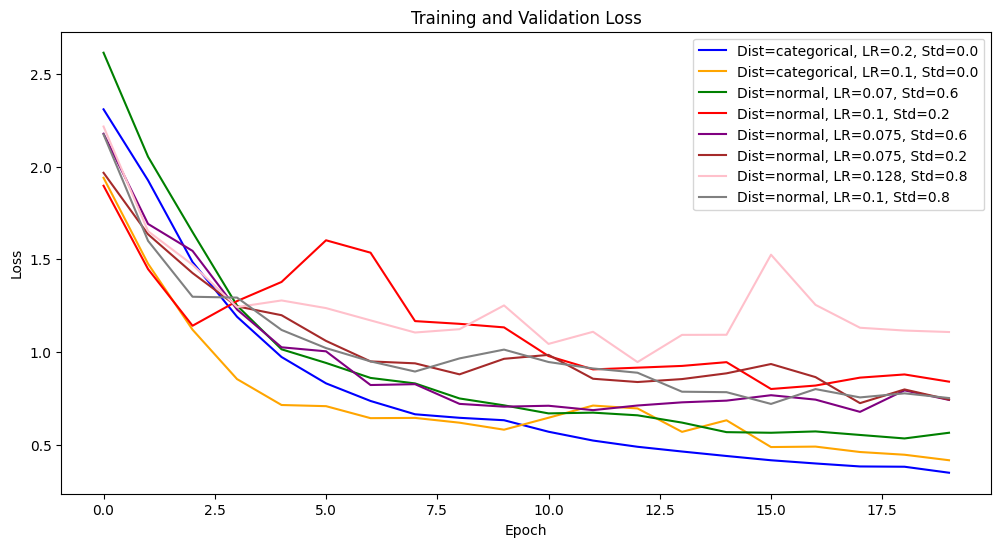

In [10]:


files = [
    './2025_12_03/16/categorical/003',
    './2026_01_27/16/categorical/mnist/007_59_b_lr_0.1',
    './2026_01_27/16/normal/mnist/001',
    #'./2025_12_03/16/normal/400x640/upscale2/003',
    #'./2025_12_03/16/normal/400x640/upscale2/006',
    './2025_12_03/16/normal/400x640/upscale2/007',
    './2025_12_03/16/normal/400x640/upscale2/008',
    './2025_12_03/16/normal/400x640/upscale2/009',
    './2025_12_03/16/normal/400x640/upscale2/010',
    #'./2025_12_03/16/normal/400x640/upscale2/011',
    './2025_12_03/16/normal/400x640/upscale2/012',
]

runs = []
for folder_name in files:
    print(f'Reading run {folder_name}')
    data = read_file(folder_name)
    runs.append(data)

# Plot all runs

# Colors list
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

plt.figure(figsize=(12, 6))
for i, run in enumerate(runs):
    dist = run['dist']
    lr   = run['lr']
    std  = run['std']

    data  = run['Training_Data']
    loss  = -data['Loss']
    epoch = data['Epoch']


    # Train and Validation should share the same color
    color = colors[i % len(colors)]

    plt.plot(epoch, loss, label=f'Dist={dist}, LR={lr}, Std={std}', color=color)
    #plt.plot(run['epoch'], run['val_loss'], label=f'Dist={dist}, LR={lr}, Std={std} (Val)', linestyle='--', color=color)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


In [29]:
# Print final results for all runs
for i, run in enumerate(runs):
    final_train_loss = run['train_loss'][-1]
    final_val_loss = run['val_loss'][-1]
    final_train_acc = run['train_acc'][-1]
    final_val_acc = run['val_acc'][-1]
    final_test_acc = run['test_acc']
    print(f'Run {i+6}: Dist={run["dist"]}, Std={run["std"]}, Quant={run["quant"]}, Lr={run["lr"]}')
    print(f'  Final Training Loss: {final_train_loss:.4f}, Final Validation Loss: {final_val_loss:.4f}')
    print(f'  Final Training Accuracy: {final_train_acc:.4f}, Final Validation Accuracy: {final_val_acc:.4f}')
    print(f'  Final Test Accuracy: {final_test_acc:.4f}')

    # Print maximum accuracy and minimum loss achieved during training
    max_train_acc = np.max(run['train_acc'])
    max_val_acc = np.max(run['val_acc'])
    min_train_loss = np.min(run['train_loss'])
    min_val_loss = np.min(run['val_loss'])
    print(f'  Max Training Accuracy: {max_train_acc:.4f}, Max Validation Accuracy: {max_val_acc:.4f}')
    print(f'  Min Training Loss: {min_train_loss:.4f}, Min Validation Loss: {min_val_loss:.4f}')

    # Print out model parameters (lr/std)
    print(f'  Learning Rate: {run["lr"]}, Standard Deviation: {run["std"]}')

Run 6: Dist=categorical, Std=0.0, Quant=16, Lr=0.2
  Final Training Loss: 0.3483, Final Validation Loss: 0.7229
  Final Training Accuracy: 90.1000, Final Validation Accuracy: 79.7000
  Final Test Accuracy: 76.9000
  Max Training Accuracy: 90.1000, Max Validation Accuracy: 79.7000
  Min Training Loss: 0.3483, Min Validation Loss: 0.7198
  Learning Rate: 0.2, Standard Deviation: 0.0
Run 7: Dist=normal, Std=0.6, Quant=16, Lr=0.075
  Final Training Loss: 0.7414, Final Validation Loss: 1.0895
  Final Training Accuracy: 77.3000, Final Validation Accuracy: 70.0000
  Final Test Accuracy: 69.3000
  Max Training Accuracy: 82.2000, Max Validation Accuracy: 74.4000
  Min Training Loss: 0.6768, Min Validation Loss: 0.9347
  Learning Rate: 0.075, Standard Deviation: 0.6


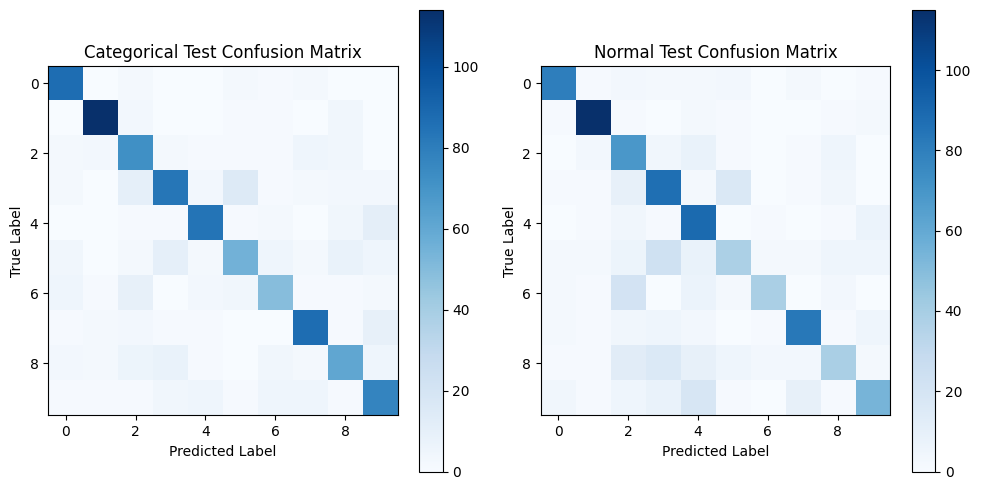

In [40]:
# Plot confusion matrices
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_run['test_conf'], cmap='Blues')
plt.title('Categorical Test Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(norm_run['test_conf'], cmap='Blues')
plt.title('Normal Test Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()
plt.tight_layout()
plt.show()

In [3]:
# Extract the best loss and store as best_16
best_16 = None
best_loss = float('inf')
for run in runs:
    if run['quant'] == 16:
        min_loss = np.min(run['val_loss'])
        if min_loss < best_loss:
            best_loss = min_loss
            best_16 = run

runs_4 = []
for i in range(1, 5):
    data = read_file (base_folder + f'{i:03d}/a/mean_reward.txt')
    print(f'Reading run {i} for quant={data["quant"]}')
    runs_4.append(data)

# Plot best_16 against each of the runs_4
plt.figure(figsize=(10, 6))
# Plot best_16
label = f"Best 16-bit: {best_16['dist']} lr={best_16['lr']}"
if best_16['std'] != 0.0:   
    label += f" std={best_16['std']}"
label += f" quant={best_16['quant']}"
plt.plot(best_16['epoch'], best_16['val_loss'], label=label, linewidth=3, color='black')
for run in runs_4:
    label = f"{run['dist']} lr={run['lr']}"
    if run['std'] != 0.0:
        label += f" std={run['std']}"
    label += f" quant={run['quant']}"
    plt.plot(run['epoch'], run['val_loss'], label=label)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


NameError: name 'base_folder' is not defined

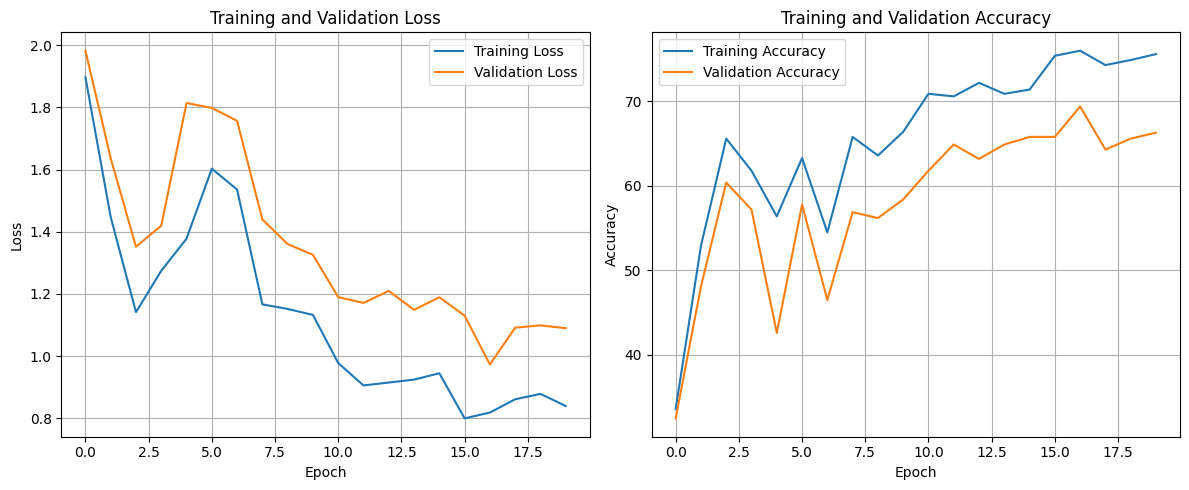

In [4]:
data = read_file(
    './2025_12_03/16/normal/400x640/upscale2/007/a/mean_reward.txt'
)


# Plot the training loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(data['epoch'], data['train_loss'], label='Training Loss')
plt.plot(data['epoch'], data['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(data['epoch'], data['train_acc'], label='Training Accuracy')
plt.plot(data['epoch'], data['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

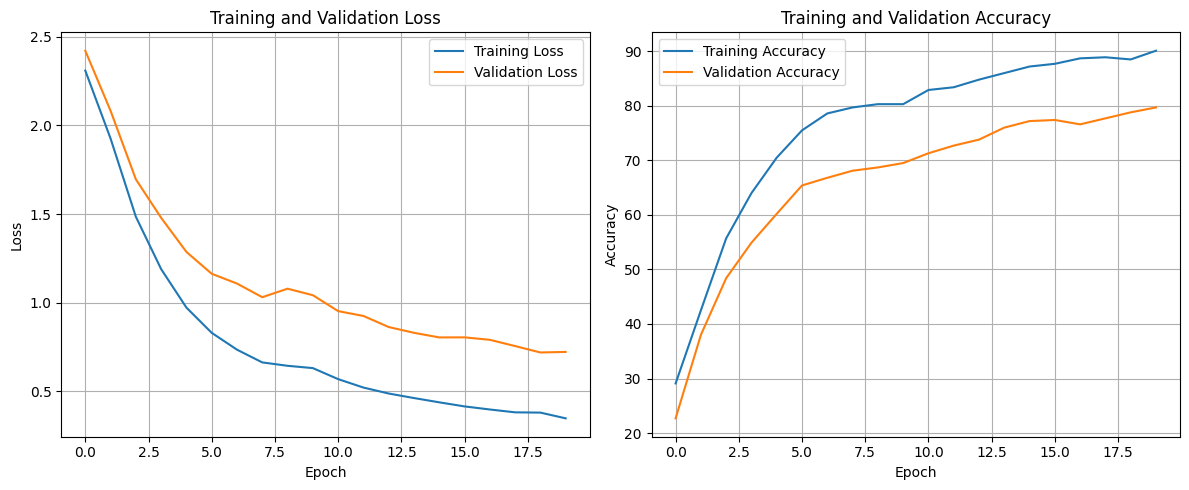

In [5]:
data = read_file(
    './2025_12_03/16/categorical/003/a/mean_reward.txt'
)


# Plot the training loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(data['epoch'], data['train_loss'], label='Training Loss')
plt.plot(data['epoch'], data['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(data['epoch'], data['train_acc'], label='Training Accuracy')
plt.plot(data['epoch'], data['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

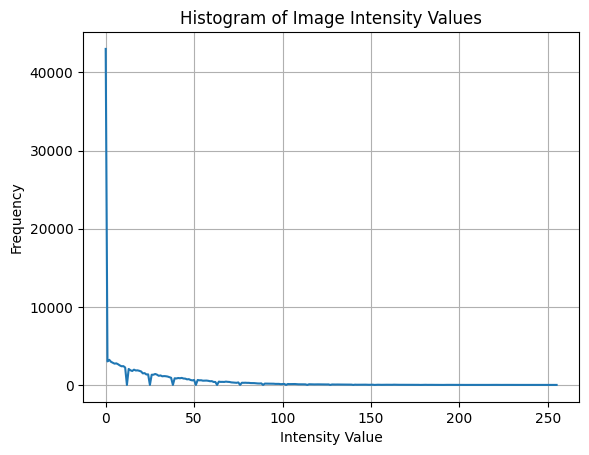

In [8]:
import cv2
img = cv2.imread('sample.bmp', cv2.IMREAD_GRAYSCALE)

# Get histogram of image intensity values
hist = cv2.calcHist([img], [0], None, [256], [0, 256])
plt.plot(hist)
plt.title('Histogram of Image Intensity Values')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')
plt.grid()
plt.show()

